In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
BASE_PATH = '../dataset'
NASA_FOLDER = os.path.join(BASE_PATH, 'dataset_nasa')
EDA_OUTPUT_FOLDER = os.path.join(BASE_PATH, 'eda_outputs')

In [ ]:
files = [
    f for f in os.listdir(NASA_FOLDER)
    if f.endswith(".csv")
]

print(f"Jumlah file NASA: {len(files)}") 

Jumlah file NASA: 514


In [6]:
all_nasa = []

for file in files:
    path = os.path.join(NASA_FOLDER, file)
    df = pd.read_csv(path)
    all_nasa.append(df)

nasa = pd.concat(all_nasa, ignore_index=True)

print(nasa.shape)    

(1501908, 8)


In [13]:
nasa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501908 entries, 0 to 1501907
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   provinsi     1501908 non-null  object        
 1   kabupaten    1501908 non-null  object        
 2   latitude     1501908 non-null  float64       
 3   longitude    1501908 non-null  float64       
 4   date         1501908 non-null  datetime64[ns]
 5   PRECTOTCORR  1501908 non-null  float64       
 6   T2M          1501908 non-null  float64       
 7   RH2M         1501908 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(2)
memory usage: 91.7+ MB


In [7]:
nasa["date"] = pd.to_datetime(
    nasa["date"]
)

In [8]:
print(
    nasa["date"].min()
)

print(
    nasa["date"].max()
)

2018-01-01 00:00:00
2025-12-31 00:00:00


In [14]:
print("="*5+" Cek Kolom yang Kosong "+ "="*5)
print(nasa.isnull().sum())

===== Cek Kolom yang Kosong =====
provinsi       0
kabupaten      0
latitude       0
longitude      0
date           0
PRECTOTCORR    0
T2M            0
RH2M           0
dtype: int64


In [11]:
nasa.head()

,provinsi,kabupaten,latitude,longitude,date,PRECTOTCORR,T2M,RH2M
0,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-01,2.55,24.54,86.11
1,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-02,7.93,24.86,85.58
2,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-03,37.44,24.47,83.77
3,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-04,5.53,24.55,86.93
4,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-05,0.25,24.65,81.61


In [20]:
nasa = df.rename(columns={
    'latitude': 'lat',
    'longitude': 'long',
    'PRECTOTCORR': 'curah_hujan',
    'T2M': 'temp_2m',
    'RH2M': 'kelembapan_2m',
})

In [21]:
print(
    nasa[
        ["curah_hujan",
         "temp_2m",
         "kelembapan_2m"]
    ].describe()
)

       curah_hujan      temp_2m  kelembapan_2m
count  2922.000000  2922.000000    2922.000000
mean      6.684127    26.069100      83.800236
std       9.528285     0.942498       4.987841
min       0.000000    23.120000      65.640000
25%       0.430000    25.530000      81.752500
50%       3.230000    26.110000      84.975000
75%       9.065000    26.727500      87.170000
max     100.950000    29.140000      93.510000


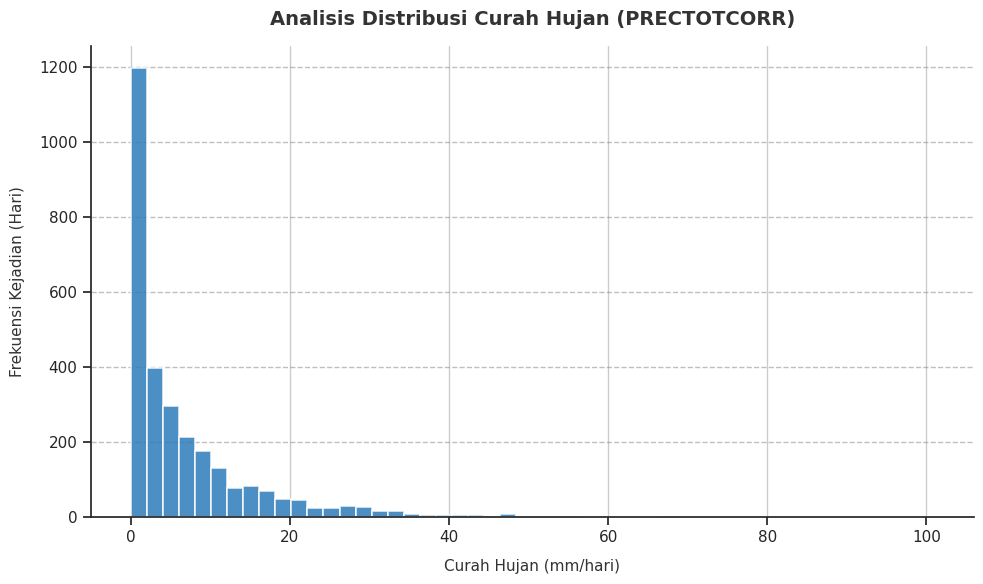

In [27]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))

nasa["curah_hujan"].hist(
    bins=50, 
    color='#2b7bba', 
    edgecolor='white', 
    linewidth=1.2, 
    alpha=0.85
)

plt.title(
    "Analisis Distribusi Curah Hujan (PRECTOTCORR)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15, 
    color='#333333'
)

plt.xlabel("Curah Hujan (mm/hari)", fontsize=11, labelpad=10, color='#333333')
plt.ylabel("Frekuensi Kejadian (Hari)", fontsize=11, labelpad=10, color='#333333')

# Hanya memunculkan grid horizontal (sumbu Y) agar grafik tidak terlihat penuh/sesak
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_FOLDER, 'distribusi_curah_hujan.png'), dpi=300, bbox_inches='tight')
plt.show()

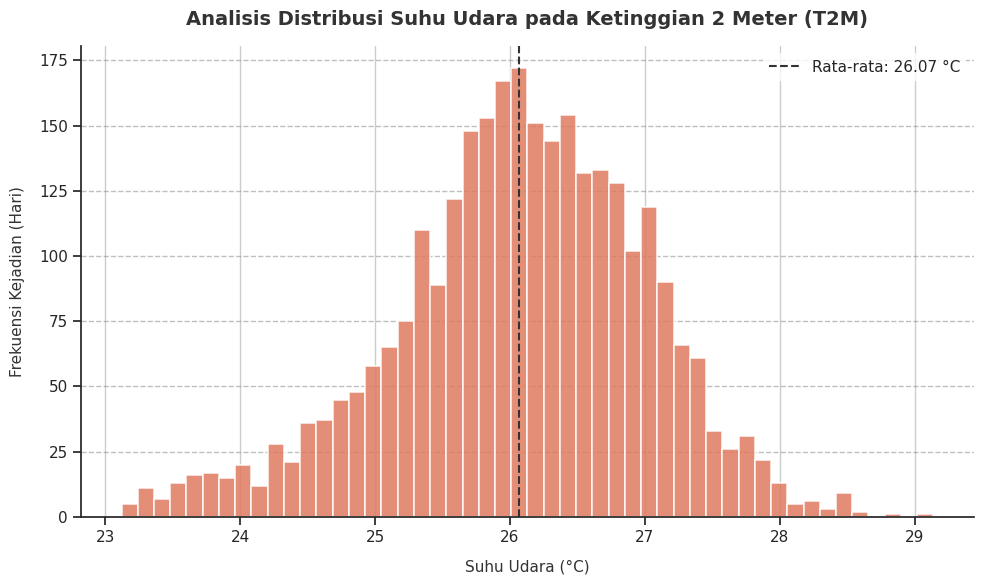

In [28]:
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

suhu_rata_rata = nasa["temp_2m"].mean()
nasa["temp_2m"].hist(
    bins=50, 
    color='#e07a5f', 
    edgecolor='white', 
    linewidth=1.2, 
    alpha=0.85
)

plt.axvline(
    suhu_rata_rata, 
    color='#333333', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Rata-rata: {suhu_rata_rata:.2f} °C'
)

plt.title(
    "Analisis Distribusi Suhu Udara pada Ketinggian 2 Meter (T2M)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15, 
    color='#333333'
)

plt.xlabel("Suhu Udara (°C)", fontsize=11, labelpad=10, color='#333333')
plt.ylabel("Frekuensi Kejadian (Hari)", fontsize=11, labelpad=10, color='#333333')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(EDA_OUTPUT_FOLDER, 'distribusi_suhu_udara.png'), dpi=300, bbox_inches='tight')
plt.show()